# AtlasIQ — Intelligent Data Analytics & Decision Support

## Project Overview

AtlasIQ is a python-based data analytics project designed to transform
raw business data into meaningful insights, visualizations, and
data-driven recommendations.

## Objectives

- Clean and prepare raw business data
- Perform exploratory data analysis (EDA)
- Identify important trends and patterns
- Analyze customer, product, and regional performance
- Detect unusual and anomalous patterns
- Perform predictive analysis
- Generate actionable insights and recommendations

## Technology Stack

- Python
- Jupyter Notebook
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("AtlasIQ environment is ready!")

AtlasIQ environment is ready!


## 1. Business Problem

Modern businesses generate large volumes of transactional data.
However, raw data alone does not provide meaningful business value.

AtlasIQ analyzes business transaction data to identify:

- Revenue and profit trends
- Product performance
- Regional performance
- Customer purchasing behavior
- Monthly and seasonal patterns
- High-value customers and products
- Unusual transaction patterns
- Factors associated with business performance

### Key Questions

1. Which products generate the highest revenue and profit?
2. Which regions perform best?
3. How does revenue change over time?
4. Which customers contribute the most revenue?
5. Which products have strong sales but weak profitability?
6. Are there unusual transaction patterns?
7. What actionable recommendations can be derived from the data?

## 2. Dataset

The dataset contains business transaction records including
customer information, product details, sales quantities,
pricing, discounts, revenue, cost, and profit.

### Expected Data Fields

| Column | Description |
|---|---|
| Order_ID | Unique transaction identifier |
| Order_Date | Date of the transaction |
| Customer_ID | Unique customer identifier |
| Region | Customer/transaction region |
| Category | Product category |
| Product | Product name |
| Quantity | Number of units sold |
| Unit_Price | Price per unit |
| Discount | Discount applied |
| Revenue | Revenue generated |
| Cost | Cost associated with the transaction |
| Profit | Profit generated |
| Payment_Method | Payment method used |

In [2]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 2000

regions = ["North", "South", "East", "West", "Central"]
categories = ["Electronics", "Furniture", "Office Supplies", "Accessories"]
products = {
    "Electronics": ["Laptop", "Monitor", "Keyboard", "Headphones"],
    "Furniture": ["Desk", "Chair", "Bookshelf", "Cabinet"],
    "Office Supplies": ["Notebook", "Printer Paper", "Stapler", "Pen Set"],
    "Accessories": ["Mouse", "Webcam", "USB Hub", "Laptop Stand"]
}
payment_methods = ["Credit Card", "Debit Card", "UPI", "Net Banking"]

dates = pd.date_range("2024-01-01", "2025-12-31", freq="D")

category_choices = np.random.choice(categories, n)

data = []

for i in range(n):
    category = category_choices[i]
    product = np.random.choice(products[category])
    quantity = np.random.randint(1, 10)
    unit_price = round(np.random.uniform(20, 1500), 2)
    discount = round(np.random.uniform(0, 0.25), 2)
    
    revenue = round(quantity * unit_price * (1 - discount), 2)
    cost = round(revenue * np.random.uniform(0.45, 0.80), 2)
    profit = round(revenue - cost, 2)

    data.append([
        f"ORD{i+1:05d}",
        np.random.choice(dates),
        f"CUST{np.random.randint(1, 501):04d}",
        np.random.choice(regions),
        category,
        product,
        quantity,
        unit_price,
        discount,
        revenue,
        cost,
        profit,
        np.random.choice(payment_methods)
    ])

columns = [
    "Order_ID",
    "Order_Date",
    "Customer_ID",
    "Region",
    "Category",
    "Product",
    "Quantity",
    "Unit_Price",
    "Discount",
    "Revenue",
    "Cost",
    "Profit",
    "Payment_Method"
]

df = pd.DataFrame(data, columns=columns)

df.head()

,Order_ID,Order_Date,Customer_ID,Region,Category,Product,Quantity,Unit_Price,Discount,Revenue,Cost,Profit,Payment_Method
0,ORD00001,2025-04-29,CUST0374,North,Office Supplies,Stapler,8,1142.42,0.16,7677.06,5494.18,2182.88,Debit Card
1,ORD00002,2025-12-11,CUST0401,South,Accessories,Mouse,9,1417.21,0.01,12627.34,8800.64,3826.70,Credit Card
2,ORD00003,2025-11-18,CUST0328,South,Electronics,Monitor,7,70.24,0.17,408.09,226.11,181.98,UPI
3,ORD00004,2025-03-18,CUST0490,North,Office Supplies,Stapler,2,1122.70,0.01,2222.95,1354.44,868.51,Debit Card
4,ORD00005,2024-06-19,CUST0424,South,Office Supplies,Stapler,8,360.41,0.03,2796.78,1333.88,1462.90,UPI


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 2000
Columns: 13


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order_ID        2000 non-null   str           
 1   Order_Date      2000 non-null   datetime64[us]
 2   Customer_ID     2000 non-null   str           
 3   Region          2000 non-null   str           
 4   Category        2000 non-null   str           
 5   Product         2000 non-null   str           
 6   Quantity        2000 non-null   int64         
 7   Unit_Price      2000 non-null   float64       
 8   Discount        2000 non-null   float64       
 9   Revenue         2000 non-null   float64       
 10  Cost            2000 non-null   float64       
 11  Profit          2000 non-null   float64       
 12  Payment_Method  2000 non-null   str           
dtypes: datetime64[us](1), float64(5), int64(1), str(6)
memory usage: 203.3 KB


In [5]:
df.to_csv("../data/business_sales.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


In [6]:
df = pd.read_csv("../data/business_sales.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (2000, 13)


,Order_ID,Order_Date,Customer_ID,Region,Category,Product,Quantity,Unit_Price,Discount,Revenue,Cost,Profit,Payment_Method
0,ORD00001,2025-04-29,CUST0374,North,Office Supplies,Stapler,8,1142.42,0.16,7677.06,5494.18,2182.88,Debit Card
1,ORD00002,2025-12-11,CUST0401,South,Accessories,Mouse,9,1417.21,0.01,12627.34,8800.64,3826.70,Credit Card
2,ORD00003,2025-11-18,CUST0328,South,Electronics,Monitor,7,70.24,0.17,408.09,226.11,181.98,UPI
3,ORD00004,2025-03-18,CUST0490,North,Office Supplies,Stapler,2,1122.70,0.01,2222.95,1354.44,868.51,Debit Card
4,ORD00005,2024-06-19,CUST0424,South,Office Supplies,Stapler,8,360.41,0.03,2796.78,1333.88,1462.90,UPI


## 4. Data Quality Assessment

Before performing analysis, the dataset is inspected for:

- Missing values
- Duplicate records
- Incorrect data types
- Invalid numerical values
- Basic statistical characteristics

In [7]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 2000
Number of columns: 13


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order_ID        2000 non-null   str    
 1   Order_Date      2000 non-null   str    
 2   Customer_ID     2000 non-null   str    
 3   Region          2000 non-null   str    
 4   Category        2000 non-null   str    
 5   Product         2000 non-null   str    
 6   Quantity        2000 non-null   int64  
 7   Unit_Price      2000 non-null   float64
 8   Discount        2000 non-null   float64
 9   Revenue         2000 non-null   float64
 10  Cost            2000 non-null   float64
 11  Profit          2000 non-null   float64
 12  Payment_Method  2000 non-null   str    
dtypes: float64(5), int64(1), str(7)
memory usage: 203.3 KB


### 4.1 Date Conversion

In [9]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

print("Order_Date converted successfully.")
print(df["Order_Date"].dtype)

Order_Date converted successfully.
datetime64[us]


### 4.2 Missing Value Analysis

In [10]:
missing_values = df.isnull().sum()

print("Missing values by column:")
print(missing_values)

Missing values by column:
Order_ID          0
Order_Date        0
Customer_ID       0
Region            0
Category          0
Product           0
Quantity          0
Unit_Price        0
Discount          0
Revenue           0
Cost              0
Profit            0
Payment_Method    0
dtype: int64


### 4.3 Duplicate Record Analysis

In [11]:
duplicate_count = df.duplicated().sum()

print("Duplicate records:", duplicate_count)

Duplicate records: 0


In [12]:
print("Negative quantities:", (df["Quantity"] < 0).sum())
print("Negative revenue:", (df["Revenue"] < 0).sum())
print("Negative cost:", (df["Cost"] < 0).sum())
print("Negative profit:", (df["Profit"] < 0).sum())
print("Invalid discounts:", ((df["Discount"] < 0) | (df["Discount"] > 1)).sum())

Negative quantities: 0
Negative revenue: 0
Negative cost: 0
Negative profit: 0
Invalid discounts: 0


## 5. Descriptive Statistics

Descriptive statistics are used to understand the central tendency,
dispersion, and overall distribution of numerical business metrics.

In [13]:
df.describe()

,Order_Date,Quantity,Unit_Price,Discount,Revenue,Cost,Profit
count,2000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,2025-01-02 03:31:40.800000,4.897000,753.412685,0.126885,3196.281800,2000.092230,1196.189570
min,2024-01-01 00:00:00,1.000000,20.230000,0.000000,21.270000,14.990000,6.200000
25%,2024-06-25 18:00:00,3.000000,383.755000,0.070000,998.060000,611.052500,367.802500
50%,2025-01-02 00:00:00,5.000000,743.560000,0.130000,2403.235000,1484.575000,845.620000
75%,2025-07-15 06:00:00,7.000000,1132.575000,0.190000,4786.370000,2934.912500,1712.820000
max,2025-12-31 00:00:00,9.000000,1499.570000,0.250000,13026.780000,9043.050000,6134.170000
std,NaN,2.593792,432.095062,0.071881,2702.862622,1759.473156,1079.826664


In [14]:
df[["Quantity", "Unit_Price", "Discount", "Revenue", "Cost", "Profit"]].describe()

,Quantity,Unit_Price,Discount,Revenue,Cost,Profit
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,4.897000,753.412685,0.126885,3196.281800,2000.092230,1196.189570
std,2.593792,432.095062,0.071881,2702.862622,1759.473156,1079.826664
min,1.000000,20.230000,0.000000,21.270000,14.990000,6.200000
25%,3.000000,383.755000,0.070000,998.060000,611.052500,367.802500
50%,5.000000,743.560000,0.130000,2403.235000,1484.575000,845.620000
75%,7.000000,1132.575000,0.190000,4786.370000,2934.912500,1712.820000
max,9.000000,1499.570000,0.250000,13026.780000,9043.050000,6134.170000


## 6. Feature Engineering

Additional business metrics are derived from the raw transaction data
to support deeper analysis.

In [15]:
df["Profit_Margin"] = np.where(
    df["Revenue"] != 0,
    (df["Profit"] / df["Revenue"]) * 100,
    0
)

df["Month"] = df["Order_Date"].dt.month
df["Month_Name"] = df["Order_Date"].dt.strftime("%B")
df["Year"] = df["Order_Date"].dt.year

df["Order_Value"] = df["Revenue"]

df.head()

,Order_ID,Order_Date,Customer_ID,Region,Category,Product,Quantity,Unit_Price,Discount,Revenue,Cost,Profit,Payment_Method,Profit_Margin,Month,Month_Name,Year,Order_Value
0,ORD00001,2025-04-29,CUST0374,North,Office Supplies,Stapler,8,1142.42,0.16,7677.06,5494.18,2182.88,Debit Card,28.433801,4,April,2025,7677.06
1,ORD00002,2025-12-11,CUST0401,South,Accessories,Mouse,9,1417.21,0.01,12627.34,8800.64,3826.70,Credit Card,30.304878,12,December,2025,12627.34
2,ORD00003,2025-11-18,CUST0328,South,Electronics,Monitor,7,70.24,0.17,408.09,226.11,181.98,UPI,44.593104,11,November,2025,408.09
3,ORD00004,2025-03-18,CUST0490,North,Office Supplies,Stapler,2,1122.70,0.01,2222.95,1354.44,868.51,Debit Card,39.070155,3,March,2025,2222.95
4,ORD00005,2024-06-19,CUST0424,South,Office Supplies,Stapler,8,360.41,0.03,2796.78,1333.88,1462.90,UPI,52.306581,6,June,2024,2796.78


In [16]:
df[[
    "Revenue",
    "Profit",
    "Profit_Margin",
    "Month",
    "Month_Name",
    "Year"
]].head()

,Revenue,Profit,Profit_Margin,Month,Month_Name,Year
0,7677.06,2182.88,28.433801,4,April,2025
1,12627.34,3826.70,30.304878,12,December,2025
2,408.09,181.98,44.593104,11,November,2025
3,2222.95,868.51,39.070155,3,March,2025
4,2796.78,1462.90,52.306581,6,June,2024


In [17]:
quality_summary = pd.DataFrame({
    "Metric": [
        "Total Rows",
        "Total Columns",
        "Missing Values",
        "Duplicate Rows",
        "Negative Revenue",
        "Negative Cost"
    ],
    "Value": [
        len(df),
        len(df.columns),
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        (df["Revenue"] < 0).sum(),
        (df["Cost"] < 0).sum()
    ]
})

quality_summary

,Metric,Value
0,Total Rows,2000
1,Total Columns,18
2,Missing Values,0
3,Duplicate Rows,0
4,Negative Revenue,0
5,Negative Cost,0


## 7. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the
distribution, relationships, trends, and patterns present in the
business data.

The analysis focuses on revenue, profit, products, categories,
regions, customers, and payment methods.

In [18]:
total_revenue = df["Revenue"].sum()
total_cost = df["Cost"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order_ID"].nunique()
total_customers = df["Customer_ID"].nunique()

print("========== ATLASIQ BUSINESS KPIs ==========")
print(f"Total Orders      : {total_orders:,}")
print(f"Total Customers   : {total_customers:,}")
print(f"Total Revenue     : ${total_revenue:,.2f}")
print(f"Total Cost        : ${total_cost:,.2f}")
print(f"Total Profit      : ${total_profit:,.2f}")
print(f"Profit Margin     : {(total_profit / total_revenue) * 100:.2f}%")

========== ATLASIQ BUSINESS KPIs ==========
Total Orders      : 2,000
Total Customers   : 489
Total Revenue     : $6,392,563.60
Total Cost        : $4,000,184.46
Total Profit      : $2,392,379.14
Profit Margin     : 37.42%


### 7.1 Revenue by Product Category

This analysis identifies which product categories contribute the most
to overall revenue.

In [19]:
category_revenue = (
    df.groupby("Category")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

category_revenue

Category
Electronics        1727600.19
Furniture          1634998.80
Office Supplies    1521121.94
Accessories        1508842.67
Name: Revenue, dtype: float64

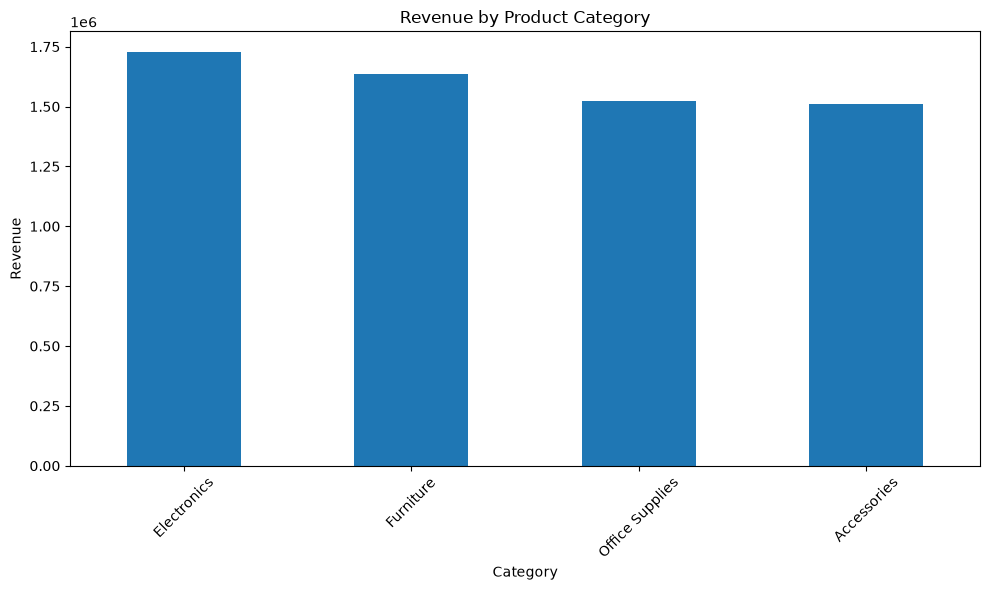

In [20]:
plt.figure(figsize=(10, 6))

category_revenue.plot(kind="bar")

plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [21]:
top_category = category_revenue.idxmax()
top_category_revenue = category_revenue.max()

print(
    f"Insight: {top_category} generates the highest revenue "
    f"with ${top_category_revenue:,.2f}."
)

Insight: Electronics generates the highest revenue with $1,727,600.19.


### 7.2 Profitability by Category

In [22]:
category_profit = (
    df.groupby("Category")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

category_profit

Category
Electronics        652123.56
Furniture          610542.02
Accessories        570633.71
Office Supplies    559079.85
Name: Profit, dtype: float64

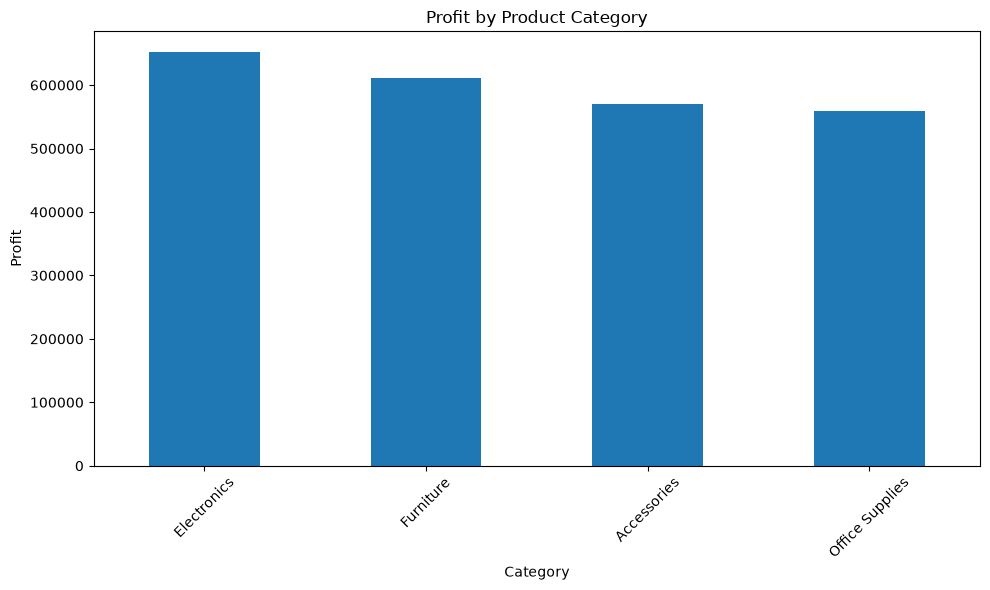

In [23]:
plt.figure(figsize=(10, 6))

category_profit.plot(kind="bar")

plt.title("Profit by Product Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [24]:
top_profit_category = category_profit.idxmax()

print(
    f"Insight: {top_profit_category} is the most profitable category."
)

Insight: Electronics is the most profitable category.


### 7.3 Regional Revenue Performance

Regional analysis helps identify geographic markets contributing most
to business revenue.

In [25]:
regional_revenue = (
    df.groupby("Region")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

regional_revenue

Region
Central    1398933.97
South      1334474.23
West       1292195.97
North      1217348.51
East       1149610.92
Name: Revenue, dtype: float64

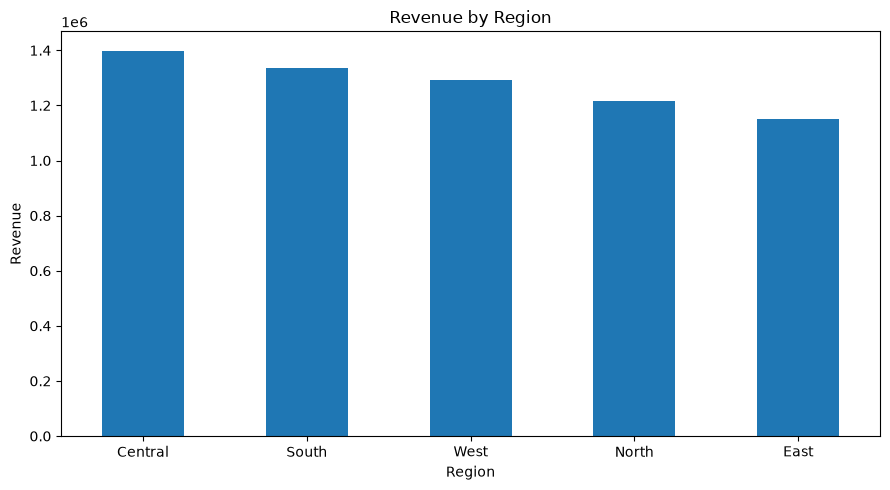

In [26]:
plt.figure(figsize=(9, 5))

regional_revenue.plot(kind="bar")

plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [27]:
best_region = regional_revenue.idxmax()

print(f"Insight: {best_region} generates the highest regional revenue.")

Insight: Central generates the highest regional revenue.


### 7.4 Product Performance

Product-level analysis identifies products that contribute strongly
to revenue and profitability.

In [28]:
product_performance = (
    df.groupby("Product")
      .agg(
          Revenue=("Revenue", "sum"),
          Profit=("Profit", "sum"),
          Quantity=("Quantity", "sum")
      )
      .sort_values("Revenue", ascending=False)
)

product_performance

,Revenue,Profit,Quantity
Product,,,
Keyboard,475154.44,177991.23,717
Bookshelf,447640.50,164002.10,632
Headphones,437421.22,162995.54,656
Monitor,433141.80,163500.50,651
Chair,416125.87,149667.60,639
Mouse,410003.83,149017.19,619
Cabinet,397595.50,153513.24,578
Printer Paper,392226.04,140176.17,606
Webcam,385168.08,145650.63,626


In [29]:
product_performance.head(10)

,Revenue,Profit,Quantity
Product,,,
Keyboard,475154.44,177991.23,717
Bookshelf,447640.50,164002.10,632
Headphones,437421.22,162995.54,656
Monitor,433141.80,163500.50,651
Chair,416125.87,149667.60,639
Mouse,410003.83,149017.19,619
Cabinet,397595.50,153513.24,578
Printer Paper,392226.04,140176.17,606
Webcam,385168.08,145650.63,626


### 7.5 Monthly Revenue Trend

Monthly revenue analysis is used to identify changes in business
performance over time.

In [30]:
monthly_revenue = (
    df.groupby(["Year", "Month"])["Revenue"]
      .sum()
      .reset_index()
)

monthly_revenue["Period"] = (
    monthly_revenue["Year"].astype(str)
    + "-"
    + monthly_revenue["Month"].astype(str).str.zfill(2)
)

monthly_revenue

,Year,Month,Revenue,Period
0,2024,1,282966.71,2024-01
1,2024,2,292507.11,2024-02
2,2024,3,238092.19,2024-03
3,2024,4,299290.97,2024-04
4,2024,5,283972.80,2024-05
5,2024,6,320711.17,2024-06
6,2024,7,221650.98,2024-07
7,2024,8,278251.88,2024-08
8,2024,9,279961.10,2024-09
9,2024,10,225133.22,2024-10


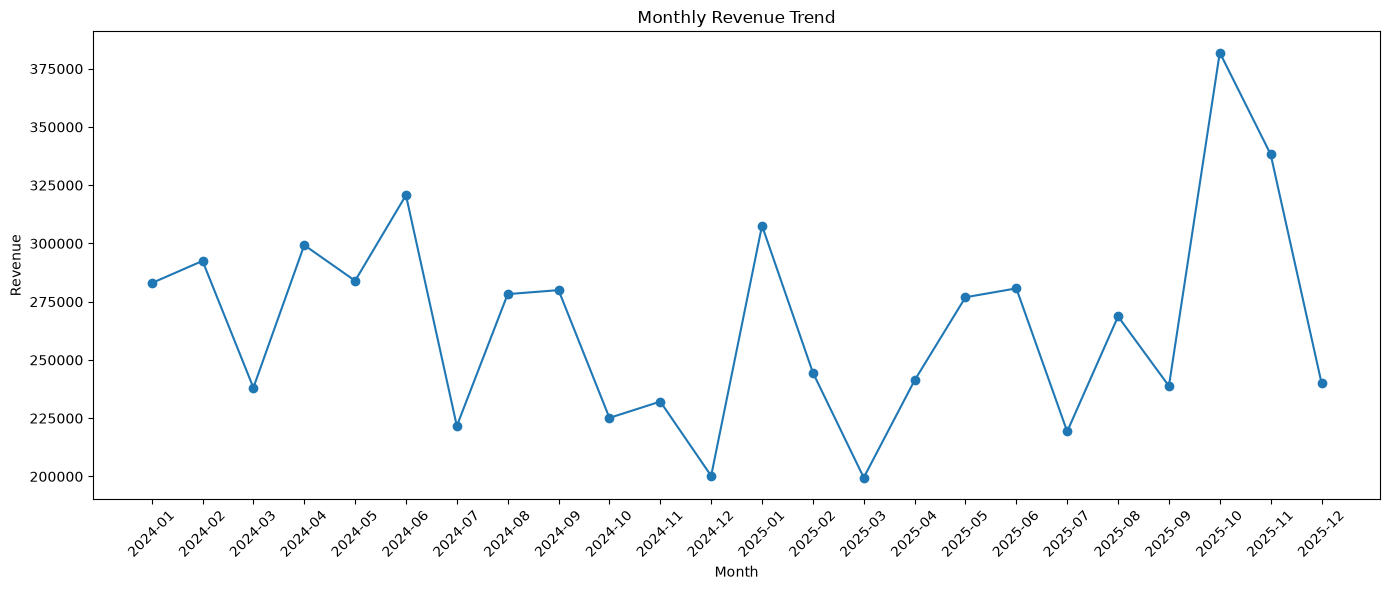

In [31]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_revenue["Period"],
    monthly_revenue["Revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [32]:
best_month = monthly_revenue.loc[
    monthly_revenue["Revenue"].idxmax()
]

print(
    f"Highest revenue period: {best_month['Period']} "
    f"with ${best_month['Revenue']:,.2f}"
)

Highest revenue period: 2025-10 with $381,919.07


### 7.6 Customer Performance Analysis

Customer-level analysis identifies high-value customers and helps
understand their contribution to overall business performance.

In [33]:
customer_performance = (
    df.groupby("Customer_ID")
      .agg(
          Total_Revenue=("Revenue", "sum"),
          Total_Profit=("Profit", "sum"),
          Total_Orders=("Order_ID", "nunique"),
          Total_Quantity=("Quantity", "sum")
      )
      .sort_values("Total_Revenue", ascending=False)
)

customer_performance.head(10)

,Total_Revenue,Total_Profit,Total_Orders,Total_Quantity
Customer_ID,,,,
CUST0234,40797.99,14303.42,9,48
CUST0082,40738.14,16299.50,9,44
CUST0432,38498.68,14822.33,13,53
CUST0156,37853.67,14053.19,9,56
CUST0220,36997.19,12162.87,9,43
CUST0202,36928.69,17263.41,8,47
CUST0472,35967.21,13819.54,8,50
CUST0401,34466.90,11558.11,7,44
CUST0379,33870.35,13601.58,10,45


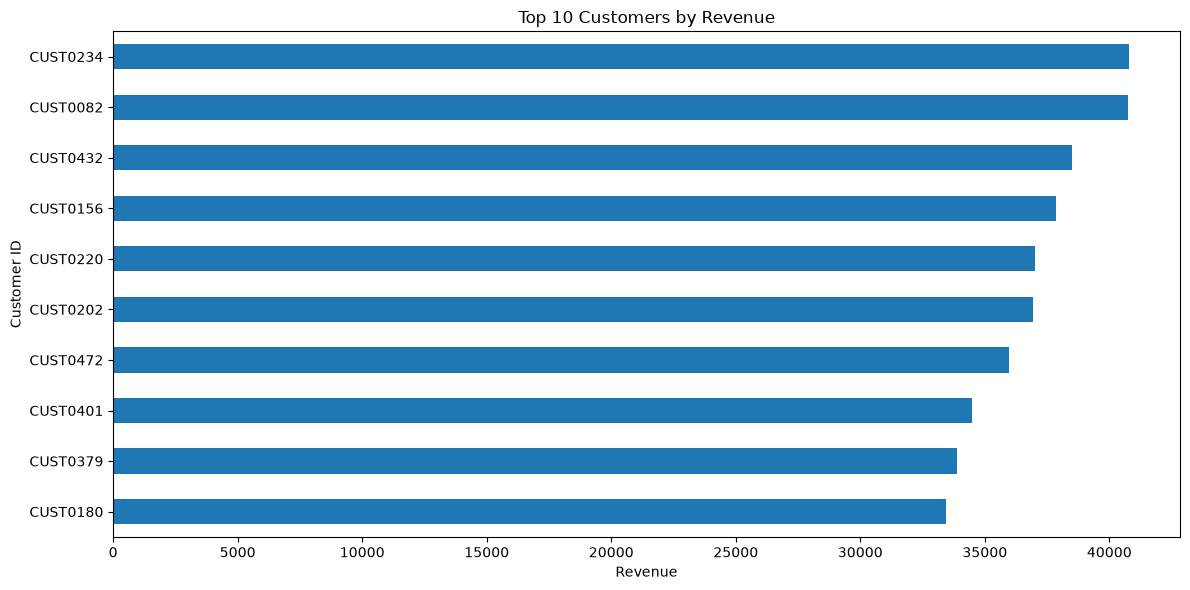

In [34]:
top_customers = customer_performance.head(10)

plt.figure(figsize=(12, 6))

top_customers["Total_Revenue"].sort_values().plot(kind="barh")

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Customer ID")
plt.tight_layout()

plt.show()

### 7.7 Payment Method Analysis

Payment-method analysis helps understand how customers complete
transactions and which payment channels are most frequently used.

In [35]:
payment_analysis = (
    df.groupby("Payment_Method")
      .agg(
          Orders=("Order_ID", "nunique"),
          Revenue=("Revenue", "sum"),
          Profit=("Profit", "sum")
      )
      .sort_values("Revenue", ascending=False)
)

payment_analysis

,Orders,Revenue,Profit
Payment_Method,,,
Net Banking,514,1772762.23,661915.09
Debit Card,497,1584421.42,588814.33
Credit Card,491,1522215.71,574928.46
UPI,498,1513164.24,566721.26


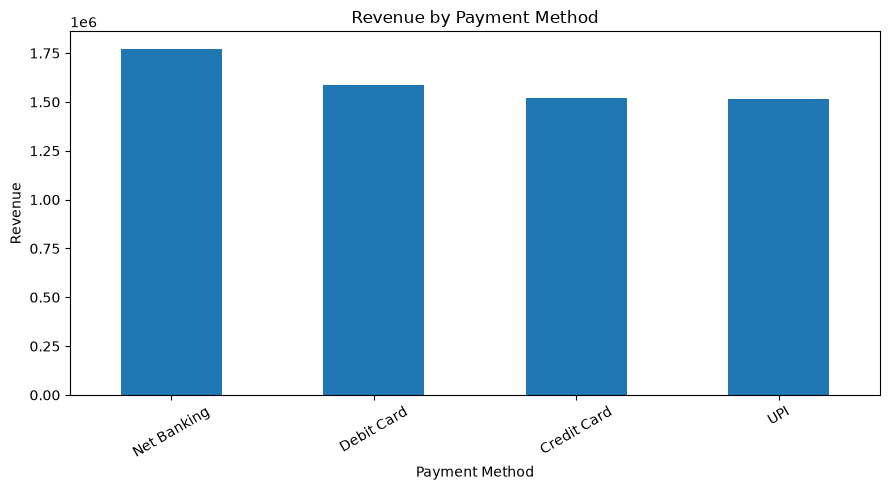

In [36]:
plt.figure(figsize=(9, 5))

payment_analysis["Revenue"].plot(kind="bar")

plt.title("Revenue by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Revenue")
plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

### 7.8 Quantity vs Revenue Relationship

This analysis examines the relationship between the number of units
sold and the revenue generated from transactions.

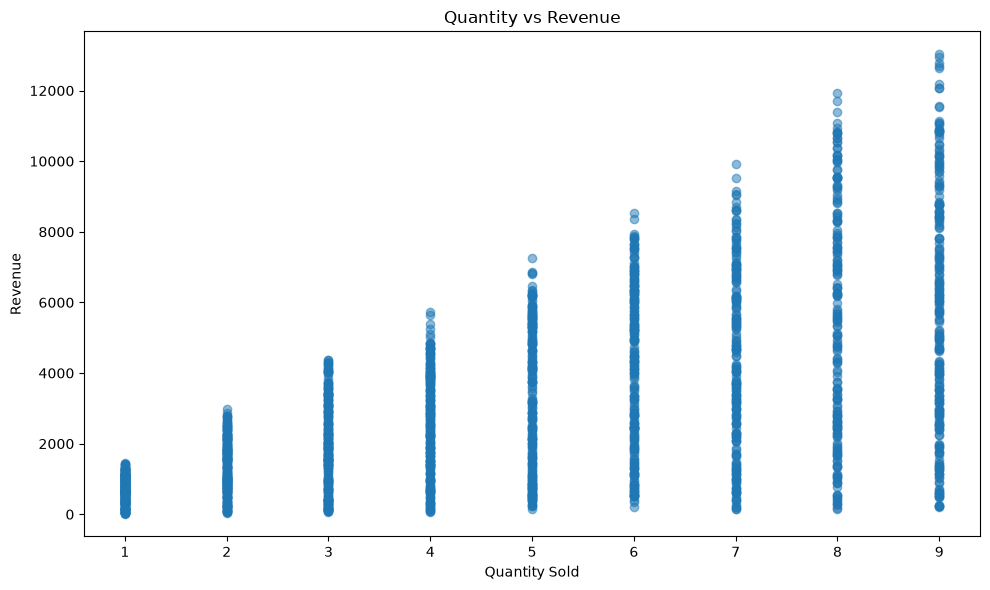

In [37]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Quantity"],
    df["Revenue"],
    alpha=0.5
)

plt.title("Quantity vs Revenue")
plt.xlabel("Quantity Sold")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

### 7.9 Revenue vs Profit Relationship

Revenue alone does not determine business success. This analysis
examines whether higher revenue transactions also generate higher
profit.

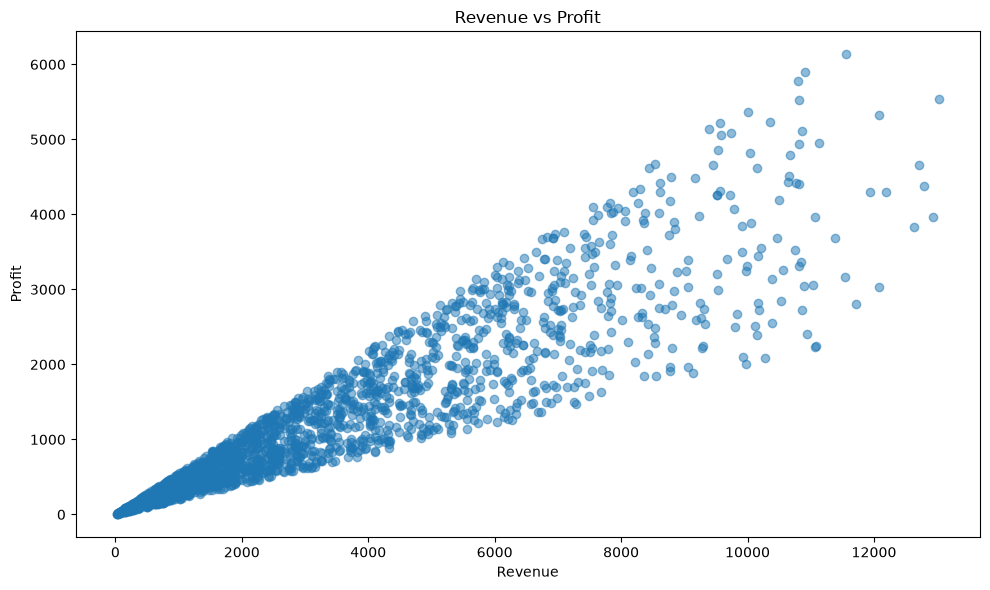

In [38]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Revenue"],
    df["Profit"],
    alpha=0.5
)

plt.title("Revenue vs Profit")
plt.xlabel("Revenue")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

## 8. Correlation Analysis

Correlation analysis is used to identify relationships between
important numerical business variables.

In [39]:
numeric_columns = [
    "Quantity",
    "Unit_Price",
    "Discount",
    "Revenue",
    "Cost",
    "Profit",
    "Profit_Margin"
]

correlation_matrix = df[numeric_columns].corr()

correlation_matrix

,Quantity,Unit_Price,Discount,Revenue,Cost,Profit,Profit_Margin
Quantity,1.000000,-0.023609,0.014645,0.617240,0.600467,0.566580,-0.031277
Unit_Price,-0.023609,1.000000,0.006542,0.671464,0.645912,0.628258,-0.005966
Discount,0.014645,0.006542,1.000000,-0.091653,-0.093969,-0.076299,0.007775
Revenue,0.617240,0.671464,-0.091653,1.000000,0.970977,0.920939,-0.036653
Cost,0.600467,0.645912,-0.093969,0.970977,1.000000,0.801004,-0.218584
Profit,0.566580,0.628258,-0.076299,0.920939,0.801004,1.000000,0.264416
Profit_Margin,-0.031277,-0.005966,0.007775,-0.036653,-0.218584,0.264416,1.000000


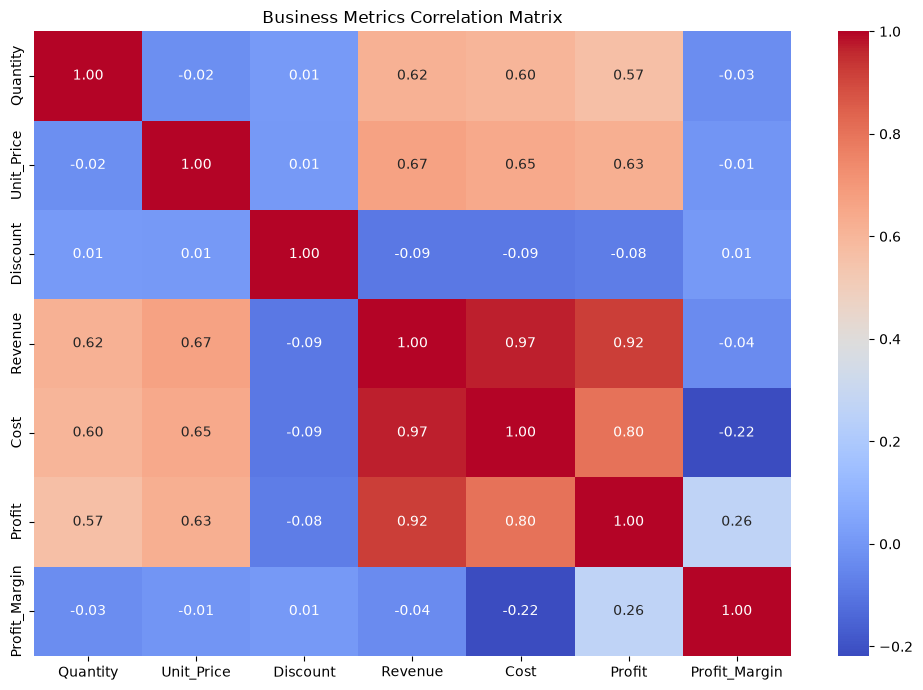

In [40]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Business Metrics Correlation Matrix")
plt.tight_layout()

plt.show()

In [41]:
corr_pairs = (
    correlation_matrix
    .where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)

print("Strongest positive relationships:")
print(corr_pairs.head(5))

Strongest positive relationships:
Revenue     Cost       0.970977
            Profit     0.920939
Cost        Profit     0.801004
Unit_Price  Revenue    0.671464
            Cost       0.645912
dtype: float64


In [42]:
print("\nStrongest negative relationships:")
print(corr_pairs.sort_values().head(5))


Strongest negative relationships:
Cost      Profit_Margin   -0.218584
Discount  Cost            -0.093969
          Revenue         -0.091653
          Profit          -0.076299
Revenue   Profit_Margin   -0.036653
dtype: float64


## 9. Key EDA Findings

The exploratory analysis evaluates customer behavior, regional
performance, product performance, payment methods, revenue trends,
profitability, and relationships between numerical business metrics.

The findings from these analyses will be used to guide the subsequent
anomaly detection and predictive analytics stages.

In [43]:
print("========== KEY EDA FINDINGS ==========\n")

print(f"1. Total revenue generated: ${df['Revenue'].sum():,.2f}")

print(f"2. Total profit generated: ${df['Profit'].sum():,.2f}")

print(
    f"3. Overall profit margin: "
    f"{(df['Profit'].sum() / df['Revenue'].sum()) * 100:.2f}%"
)

========== KEY EDA FINDINGS ==========

1. Total revenue generated: $6,392,563.60
2. Total profit generated: $2,392,379.14
3. Overall profit margin: 37.42%


In [44]:
best_category = (
    df.groupby("Category")["Revenue"]
      .sum()
      .idxmax()
)

best_category_revenue = (
    df.groupby("Category")["Revenue"]
      .sum()
      .max()
)

print(
    f"4. Highest revenue category: {best_category} "
    f"(${best_category_revenue:,.2f})"
)

4. Highest revenue category: Electronics ($1,727,600.19)


In [45]:
best_region = (
    df.groupby("Region")["Revenue"]
      .sum()
      .idxmax()
)

print(f"5. Highest revenue region: {best_region}")

5. Highest revenue region: Central


In [46]:
best_customer = (
    df.groupby("Customer_ID")["Revenue"]
      .sum()
      .idxmax()
)

print(f"7. Highest-value customer: {best_customer}")

7. Highest-value customer: CUST0234


In [47]:
popular_payment = df["Payment_Method"].value_counts().idxmax()

print(f"8. Most frequently used payment method: {popular_payment}")

8. Most frequently used payment method: Net Banking


In [48]:
monthly_revenue = (
    df.groupby(["Year", "Month"])["Revenue"]
      .sum()
      .reset_index()
)

best_month = monthly_revenue.loc[
    monthly_revenue["Revenue"].idxmax()
]

print(
    f"9. Highest revenue period: "
    f"{int(best_month['Year'])}-{int(best_month['Month']):02d}"
)

9. Highest revenue period: 2025-10


In [49]:
revenue_profit_corr = df["Revenue"].corr(df["Profit"])

print(
    f"10. Revenue-Profit correlation: "
    f"{revenue_profit_corr:.2f}"
)

10. Revenue-Profit correlation: 0.92


# 10. Anomaly Detection

Anomaly detection is used to identify transactions that behave
significantly differently from normal business activity.

AtlasIQ uses the Isolation Forest algorithm to detect potentially
unusual transactions based on revenue, cost, profit, quantity,
unit price, and discount.

In [50]:
from sklearn.ensemble import IsolationForest

anomaly_features = [
    "Quantity",
    "Unit_Price",
    "Discount",
    "Revenue",
    "Cost",
    "Profit"
]

X = df[anomaly_features]

model = IsolationForest(
    contamination=0.02,
    random_state=42
)

df["Anomaly"] = model.fit_predict(X)

df["Anomaly_Label"] = df["Anomaly"].map({
    1: "Normal",
    -1: "Anomaly"
})

df["Anomaly_Label"].value_counts()

Anomaly_Label
Normal     1960
Anomaly      40
Name: count, dtype: int64

In [51]:
anomalies = df[df["Anomaly_Label"] == "Anomaly"]

print("Number of anomalies detected:", len(anomalies))

anomalies[
    [
        "Order_ID",
        "Region",
        "Category",
        "Product",
        "Quantity",
        "Revenue",
        "Cost",
        "Profit",
        "Discount"
    ]
].head(20)

Number of anomalies detected: 40


,Order_ID,Region,Category,Product,Quantity,Revenue,Cost,Profit,Discount
1,ORD00002,South,Accessories,Mouse,9,12627.34,8800.64,3826.70,0.01
85,ORD00086,Central,Office Supplies,Notebook,9,12937.16,8969.34,3967.82,0.03
92,ORD00093,East,Furniture,Chair,9,11126.43,6178.49,4947.94,0.00
140,ORD00141,East,Accessories,USB Hub,9,12196.23,7902.46,4293.77,0.05
296,ORD00297,South,Furniture,Chair,8,10935.05,8523.27,2411.78,0.08
305,ORD00306,East,Electronics,Monitor,6,8531.95,3864.22,4667.73,0.03
334,ORD00335,South,Furniture,Desk,8,11389.48,7709.67,3679.81,0.02
373,ORD00374,West,Accessories,Laptop Stand,9,12706.38,8042.71,4663.67,0.00
386,ORD00387,North,Office Supplies,Pen Set,9,10903.59,5001.91,5901.68,0.04
448,ORD00449,North,Office Supplies,Printer Paper,9,12785.93,8412.50,4373.43,0.05


## 10.1 Anomaly Visualization

The detected anomalies are visualized against normal transactions
to understand how unusual transactions differ from typical business
activity.

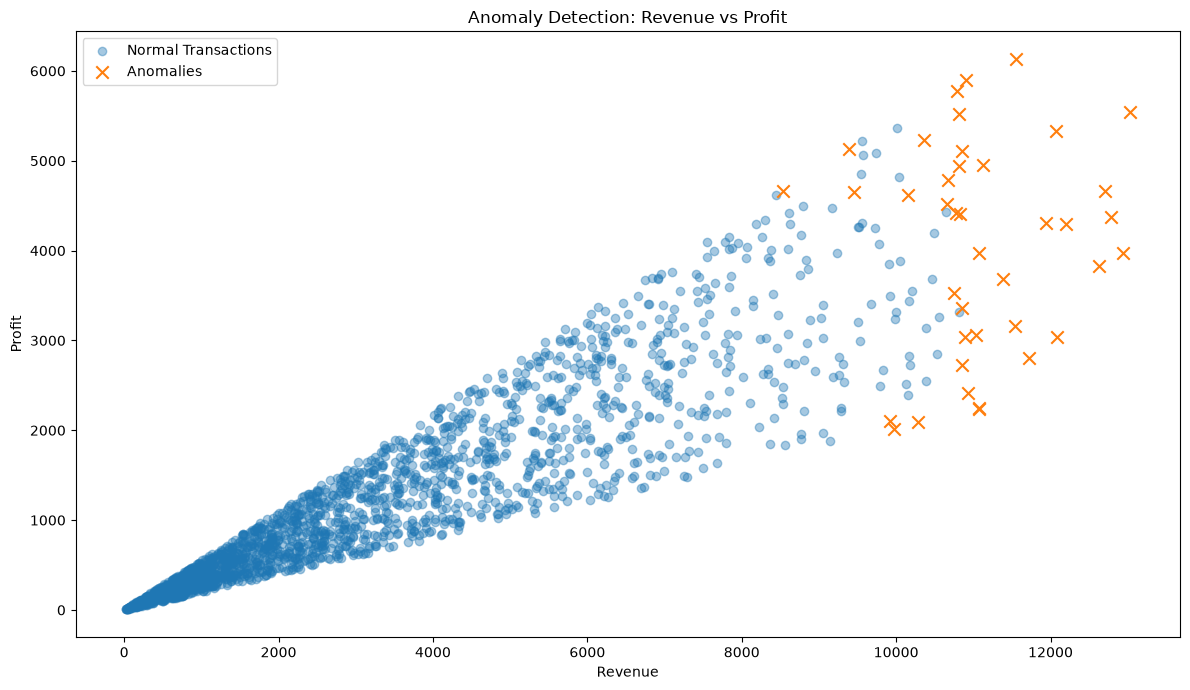

In [52]:
plt.figure(figsize=(12, 7))

normal = df[df["Anomaly_Label"] == "Normal"]
anomalies = df[df["Anomaly_Label"] == "Anomaly"]

plt.scatter(
    normal["Revenue"],
    normal["Profit"],
    alpha=0.4,
    label="Normal Transactions"
)

plt.scatter(
    anomalies["Revenue"],
    anomalies["Profit"],
    marker="x",
    s=80,
    label="Anomalies"
)

plt.title("Anomaly Detection: Revenue vs Profit")
plt.xlabel("Revenue")
plt.ylabel("Profit")
plt.legend()

plt.tight_layout()
plt.show()

### 10.2 Anomaly Analysis

The detected anomalies are further examined to understand their
characteristics and potential business significance.

In [53]:
anomaly_summary = anomalies[
    ["Quantity", "Unit_Price", "Discount", "Revenue", "Cost", "Profit"]
].describe()

anomaly_summary

,Quantity,Unit_Price,Discount,Revenue,Cost,Profit
count,40.000000,40.00000,40.000000,40.000000,40.00000,40.000000
mean,8.600000,1397.70350,0.073750,11084.779000,7020.94525,4063.833750
std,0.671775,86.33213,0.070917,984.230711,1474.06254,1175.195376
min,6.000000,1219.01000,0.000000,8531.950000,3864.22000,2010.690000
25%,8.000000,1352.33250,0.020000,10730.657500,5839.27000,3056.080000
50%,9.000000,1414.67500,0.050000,10900.080000,7487.20500,4339.055000
75%,9.000000,1467.48250,0.095000,11591.170000,8145.45500,4945.232500
max,9.000000,1499.57000,0.230000,13026.780000,9043.05000,6134.170000


In [54]:
comparison = df.groupby("Anomaly_Label")[
    ["Quantity", "Unit_Price", "Discount", "Revenue", "Cost", "Profit"]
].mean()

comparison

,Quantity,Unit_Price,Discount,Revenue,Cost,Profit
Anomaly_Label,,,,,,
Anomaly,8.600000,1397.703500,0.073750,11084.779000,7020.945250,4063.833750
Normal,4.821429,740.263893,0.127969,3035.292061,1897.625842,1137.666219


In [55]:
print("========== ANOMALY SUMMARY ==========")

print(f"Total transactions : {len(df):,}")
print(f"Anomalies detected : {len(anomalies):,}")
print(
    f"Anomaly rate       : "
    f"{len(anomalies) / len(df) * 100:.2f}%"
)

print(
    f"\nAverage anomaly revenue: "
    f"${anomalies['Revenue'].mean():,.2f}"
)

print(
    f"Average normal revenue: "
    f"${normal['Revenue'].mean():,.2f}"
)

========== ANOMALY SUMMARY ==========
Total transactions : 2,000
Anomalies detected : 40
Anomaly rate       : 2.00%

Average anomaly revenue: $11,084.78
Average normal revenue: $3,035.29


In [56]:
top_anomalies = (
    anomalies[
        [
            "Order_ID",
            "Product",
            "Category",
            "Region",
            "Quantity",
            "Revenue",
            "Profit",
            "Discount"
        ]
    ]
    .sort_values("Revenue", ascending=False)
    .head(10)
)

top_anomalies

,Order_ID,Product,Category,Region,Quantity,Revenue,Profit,Discount
965,ORD00966,Monitor,Electronics,North,9,13026.78,5542.62,0.01
85,ORD00086,Notebook,Office Supplies,Central,9,12937.16,3967.82,0.03
448,ORD00449,Printer Paper,Office Supplies,North,9,12785.93,4373.43,0.05
373,ORD00374,Laptop Stand,Accessories,West,9,12706.38,4663.67,0.00
1,ORD00002,Mouse,Accessories,South,9,12627.34,3826.70,0.01
140,ORD00141,USB Hub,Accessories,East,9,12196.23,4293.77,0.05
526,ORD00527,Pen Set,Office Supplies,North,9,12078.90,3035.85,0.02
1681,ORD01682,Chair,Furniture,North,9,12073.80,5331.54,0.05
1984,ORD01985,Cabinet,Furniture,Central,8,11934.96,4304.68,0.00
1653,ORD01654,Stapler,Office Supplies,West,8,11715.58,2808.39,0.01


### 10.3 Anomaly Findings

The Isolation Forest model identified transactions that differ
significantly from the normal transaction pattern.

These transactions require further investigation because unusual
revenue, quantity, pricing, discounts, or profitability may indicate
exceptional business activity, data-quality issues, or potentially
unusual customer behavior.

In [57]:
# Generate automated anomaly findings

total_transactions = len(df)
total_anomalies = len(anomalies)
anomaly_rate = (total_anomalies / total_transactions) * 100

average_anomaly_revenue = anomalies["Revenue"].mean()
average_normal_revenue = normal["Revenue"].mean()

average_anomaly_profit = anomalies["Profit"].mean()
average_normal_profit = normal["Profit"].mean()

print("========== ANOMALY FINDINGS ==========\n")

print(f"Total transactions       : {total_transactions:,}")
print(f"Detected anomalies       : {total_anomalies:,}")
print(f"Anomaly rate              : {anomaly_rate:.2f}%")

print(
    f"\nAverage anomaly revenue  : "
    f"${average_anomaly_revenue:,.2f}"
)

print(
    f"Average normal revenue   : "
    f"${average_normal_revenue:,.2f}"
)

print(
    f"\nAverage anomaly profit   : "
    f"${average_anomaly_profit:,.2f}"
)

print(
    f"Average normal profit    : "
    f"${average_normal_profit:,.2f}"
)

========== ANOMALY FINDINGS ==========

Total transactions       : 2,000
Detected anomalies       : 40
Anomaly rate              : 2.00%

Average anomaly revenue  : $11,084.78
Average normal revenue   : $3,035.29

Average anomaly profit   : $4,063.83
Average normal profit    : $1,137.67


In [58]:
# Identify the transaction with the highest revenue among anomalies

highest_revenue_anomaly = anomalies.loc[
    anomalies["Revenue"].idxmax()
]

print("========== HIGHEST REVENUE ANOMALY ==========\n")

print(f"Order ID     : {highest_revenue_anomaly['Order_ID']}")
print(f"Product      : {highest_revenue_anomaly['Product']}")
print(f"Category     : {highest_revenue_anomaly['Category']}")
print(f"Region       : {highest_revenue_anomaly['Region']}")
print(f"Quantity     : {highest_revenue_anomaly['Quantity']}")
print(f"Revenue      : ${highest_revenue_anomaly['Revenue']:,.2f}")
print(f"Profit       : ${highest_revenue_anomaly['Profit']:,.2f}")
print(f"Discount     : {highest_revenue_anomaly['Discount']:.2%}")

========== HIGHEST REVENUE ANOMALY ==========

Order ID     : ORD00966
Product      : Monitor
Category     : Electronics
Region       : North
Quantity     : 9
Revenue      : $13,026.78
Profit       : $5,542.62
Discount     : 1.00%


# 11. Predictive Analytics

AtlasIQ uses machine learning to predict transaction revenue based on
business attributes such as quantity, unit price, discount, cost,
product category, region, and payment method.

A Random Forest regression model is used to learn relationships between
these variables and transaction revenue.

In [59]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

ml_df = df.copy()

ml_df = pd.get_dummies(
    ml_df,
    columns=["Region", "Category", "Payment_Method"],
    drop_first=True
)

print("ML dataset shape:", ml_df.shape)

ML dataset shape: (2000, 27)


In [60]:
features = [
    "Quantity",
    "Unit_Price",
    "Discount",
    "Cost"
]

categorical_features = [
    col for col in ml_df.columns
    if col.startswith(("Region_", "Category_", "Payment_Method_"))
]

features.extend(categorical_features)

X = ml_df[features]
y = ml_df["Revenue"]

print("Features:", X.shape[1])
print("Target:", y.name)
print("Records:", X.shape[0])

Features: 14
Target: Revenue
Records: 2000


### 11.1 Train-Test Split

The dataset is divided into training and testing subsets.

The training data is used to build the model, while the testing data
is used to evaluate its performance on unseen transactions.

In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 1600
Testing records: 400


### 11.2 Random Forest Regression

Random Forest Regression is used to model potentially nonlinear
relationships between transaction attributes and revenue.

In [62]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [63]:
y_pred = model.predict(X_test)

prediction_results = pd.DataFrame({
    "Actual_Revenue": y_test.values,
    "Predicted_Revenue": y_pred
})

prediction_results.head(10)

,Actual_Revenue,Predicted_Revenue
0,4015.78,3411.34780
1,1979.57,2289.63295
2,940.61,938.38270
3,667.99,686.17865
4,2133.65,2203.12155
5,1299.86,1296.93190
6,1331.75,1634.00925
7,5670.64,6391.84920
8,602.52,723.12590
9,5212.00,5029.70255


### 11.3 Model Evaluation

The model is evaluated using Mean Absolute Error (MAE), Root Mean
Squared Error (RMSE), and R² Score.

In [64]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("========== MODEL PERFORMANCE ==========")
print(f"MAE  : ${mae:,.2f}")
print(f"RMSE : ${rmse:,.2f}")
print(f"R²   : {r2:.4f}")

========== MODEL PERFORMANCE ==========
MAE  : $237.95
RMSE : $339.46
R²   : 0.9823


### 11.4 Actual vs Predicted Revenue

The following visualization compares actual transaction revenue with
the revenue predicted by the machine learning model.

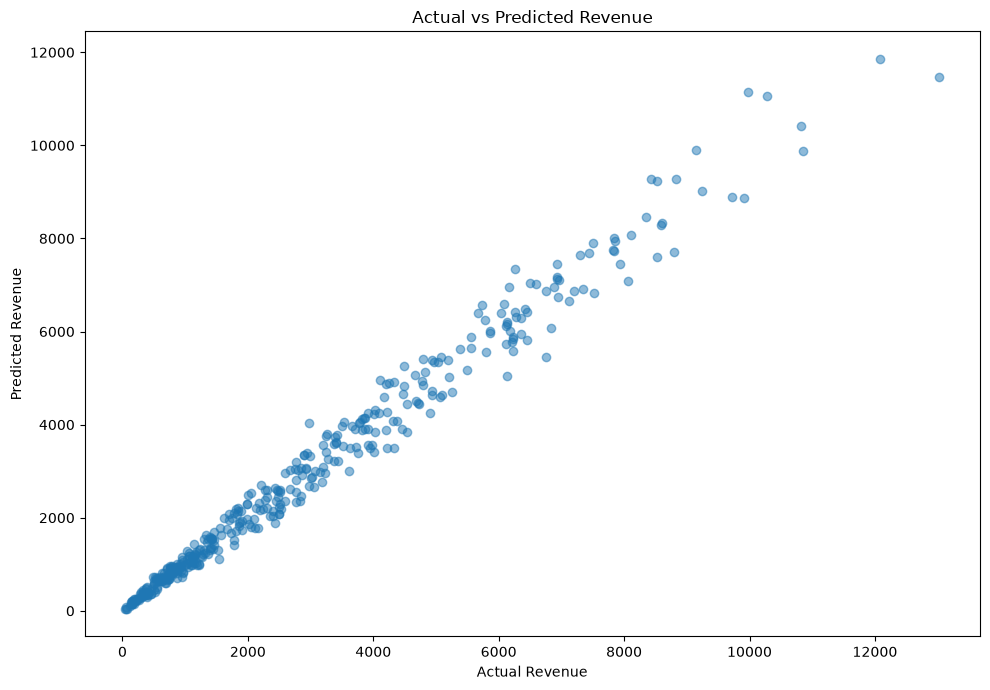

In [65]:
plt.figure(figsize=(10, 7))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title("Actual vs Predicted Revenue")

plt.tight_layout()
plt.show()

### 11.5 Feature Importance

Feature importance is analyzed to determine which variables contribute
most strongly to the Random Forest revenue predictions.

In [66]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
3,Cost,0.954639
1,Unit_Price,0.019754
0,Quantity,0.015654
2,Discount,0.005735
10,Category_Office Supplies,0.000498
12,Payment_Method_Net Banking,0.000471
5,Region_North,0.000469
8,Category_Electronics,0.000452
7,Region_West,0.000430
9,Category_Furniture,0.000407


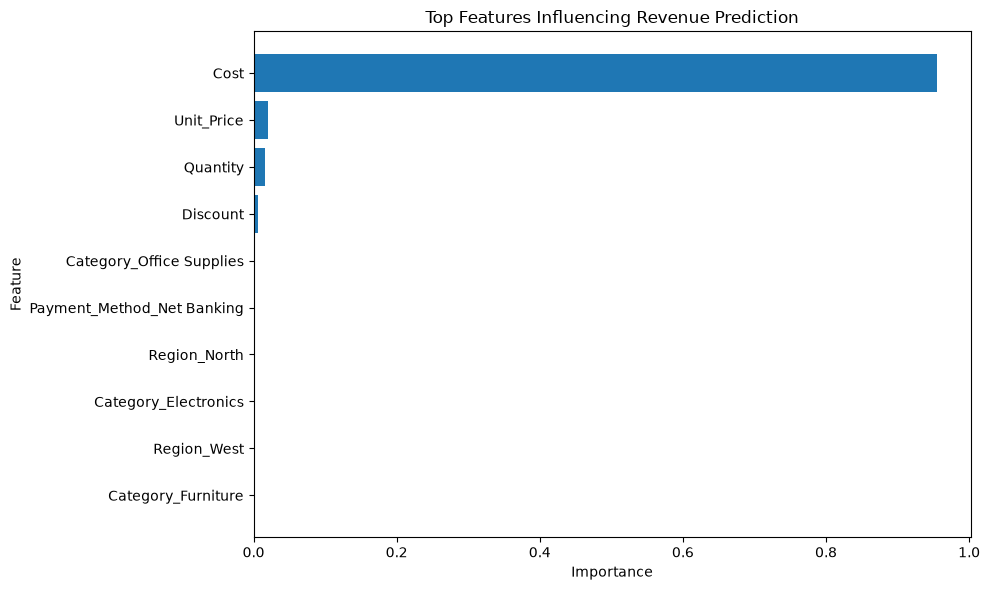

In [67]:
top_features = feature_importance.head(10).sort_values("Importance")

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top Features Influencing Revenue Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [68]:
print("========== MODEL INTERPRETATION ==========\n")

print(f"R² Score: {r2:.4f}")

if r2 >= 0.90:
    print("Model performance: Excellent")
elif r2 >= 0.75:
    print("Model performance: Good")
elif r2 >= 0.50:
    print("Model performance: Moderate")
else:
    print("Model performance: Needs improvement")

print(
    f"\nOn average, predictions differ from actual revenue "
    f"by approximately ${mae:,.2f}."
)

========== MODEL INTERPRETATION ==========

R² Score: 0.9823
Model performance: Excellent

On average, predictions differ from actual revenue by approximately $237.95.


### 11.6 Prediction Error Analysis

Prediction errors are analyzed to understand where the machine
learning model performs well and where its predictions differ most
from actual revenue.

In [69]:
prediction_results["Error"] = (
    prediction_results["Actual_Revenue"]
    - prediction_results["Predicted_Revenue"]
)

prediction_results["Absolute_Error"] = (
    prediction_results["Error"].abs()
)

prediction_results.head(10)

,Actual_Revenue,Predicted_Revenue,Error,Absolute_Error
0,4015.78,3411.34780,604.43220,604.43220
1,1979.57,2289.63295,-310.06295,310.06295
2,940.61,938.38270,2.22730,2.22730
3,667.99,686.17865,-18.18865,18.18865
4,2133.65,2203.12155,-69.47155,69.47155
5,1299.86,1296.93190,2.92810,2.92810
6,1331.75,1634.00925,-302.25925,302.25925
7,5670.64,6391.84920,-721.20920,721.20920
8,602.52,723.12590,-120.60590,120.60590
9,5212.00,5029.70255,182.29745,182.29745


In [70]:
largest_errors = prediction_results.sort_values(
    "Absolute_Error",
    ascending=False
).head(10)

largest_errors

,Actual_Revenue,Predicted_Revenue,Error,Absolute_Error
395,13026.78,11471.47020,1555.30980,1555.30980
110,6747.04,5454.04640,1292.99360,1292.99360
399,9974.44,11157.46955,-1183.02955,1183.02955
91,8796.92,7700.16735,1096.75265,1096.75265
55,6137.51,5047.99965,1089.51035,1089.51035
357,6268.05,7340.41805,-1072.36805,1072.36805
372,2968.28,4028.86670,-1060.58670,1060.58670
17,9905.41,8878.95375,1026.45625,1026.45625
158,8064.82,7082.75135,982.06865,982.06865
96,10858.89,9878.60055,980.28945,980.28945


### 11.7 Prediction Error Distribution

The distribution of prediction errors is visualized to determine
whether the model's errors are concentrated around a particular range.

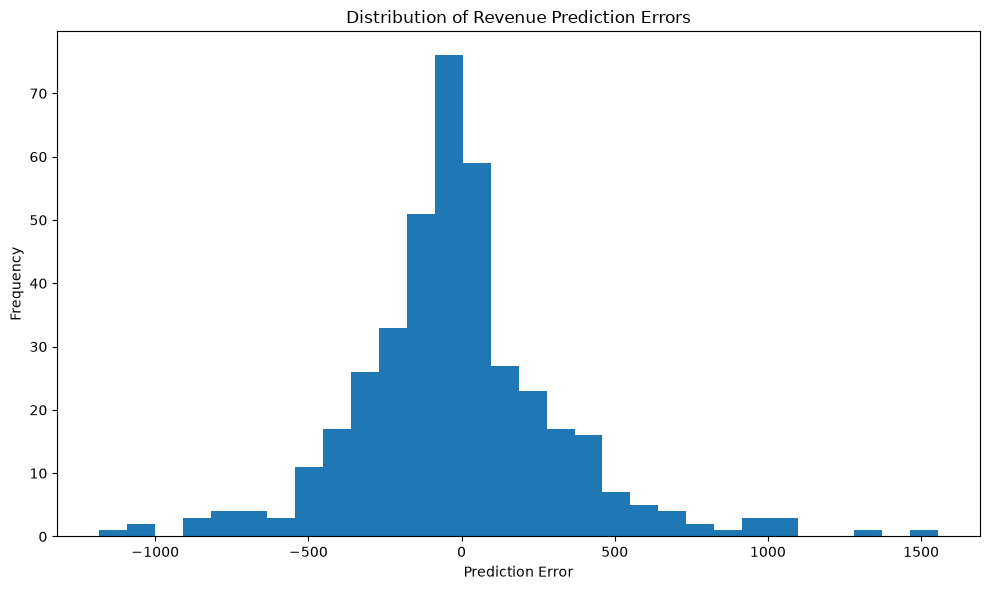

In [71]:
plt.figure(figsize=(10, 6))

plt.hist(
    prediction_results["Error"],
    bins=30
)

plt.title("Distribution of Revenue Prediction Errors")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [72]:
import os

os.makedirs("../reports", exist_ok=True)

prediction_results.to_csv(
    "../reports/revenue_predictions.csv",
    index=False
)

feature_importance.to_csv(
    "../reports/feature_importance.csv",
    index=False
)

anomalies.to_csv(
    "../reports/detected_anomalies.csv",
    index=False
)

print("ML and anomaly reports saved successfully.")

ML and anomaly reports saved successfully.


### 11.8 Predictive Analytics Findings

The Random Forest regression model was trained to estimate transaction
revenue using numerical and categorical business attributes.

Model performance was evaluated using MAE, RMSE, and R².

Feature importance analysis was used to identify the variables that
contribute most strongly to revenue prediction.

Prediction-error analysis was also performed to identify transactions
where the model's estimates differ substantially from actual revenue.

In [73]:
print("========== PREDICTIVE ANALYTICS FINDINGS ==========\n")

print(f"MAE  : ${mae:,.2f}")
print(f"RMSE : ${rmse:,.2f}")
print(f"R²   : {r2:.4f}")

print("\nTop 5 predictive features:")

for _, row in feature_importance.head(5).iterrows():
    print(
        f"- {row['Feature']}: "
        f"{row['Importance']:.4f}"
    )

========== PREDICTIVE ANALYTICS FINDINGS ==========

MAE  : $237.95
RMSE : $339.46
R²   : 0.9823

Top 5 predictive features:
- Cost: 0.9546
- Unit_Price: 0.0198
- Quantity: 0.0157
- Discount: 0.0057
- Category_Office Supplies: 0.0005


In [74]:
print("\n========== PREDICTIVE ANALYTICS INTERPRETATION ==========\n")

print(
    f"The predictive model achieved an R² score of {r2:.4f}, "
    f"indicating how well the selected features explain variations "
    f"in the target variable."
)

print(
    f"The model's average prediction error (MAE) is "
    f"${mae:,.2f}, while the RMSE is ${rmse:,.2f}."
)

print("\nMost influential factors affecting predictions:")

for _, row in feature_importance.head(5).iterrows():
    print(
        f"- {row['Feature']} has an importance score of "
        f"{row['Importance']:.4f}"
    )

print(
    "\nThese features should be monitored closely because "
    "changes in them can have a significant impact on predicted "
    "business performance."
)


========== PREDICTIVE ANALYTICS INTERPRETATION ==========

The predictive model achieved an R² score of 0.9823, indicating how well the selected features explain variations in the target variable.
The model's average prediction error (MAE) is $237.95, while the RMSE is $339.46.

Most influential factors affecting predictions:
- Cost has an importance score of 0.9546
- Unit_Price has an importance score of 0.0198
- Quantity has an importance score of 0.0157
- Discount has an importance score of 0.0057
- Category_Office Supplies has an importance score of 0.0005

These features should be monitored closely because changes in them can have a significant impact on predicted business performance.


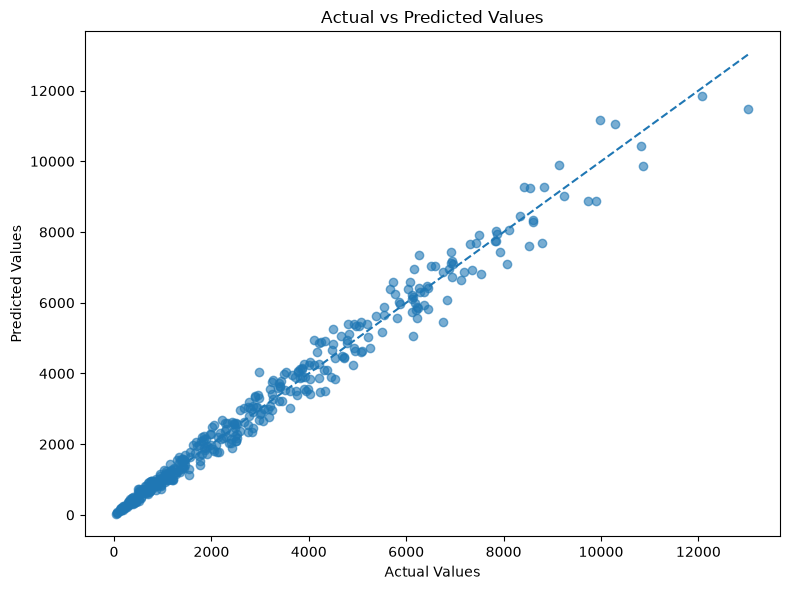

In [75]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")

plt.tight_layout()
plt.show()


========== FEATURE IMPORTANCE VISUALIZATION ==========



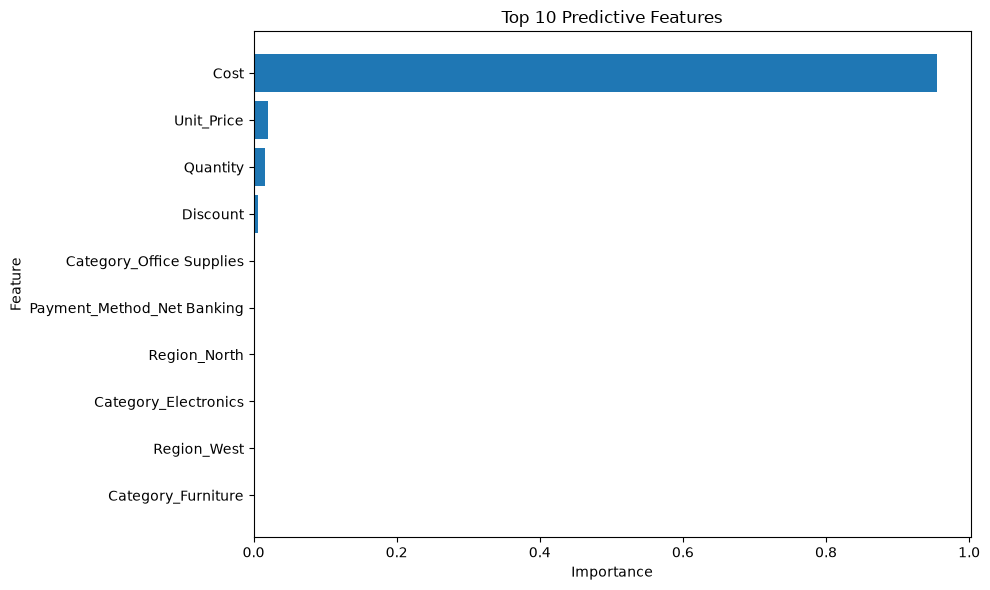

In [76]:
print("\n========== FEATURE IMPORTANCE VISUALIZATION ==========\n")

top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Predictive Features")

plt.tight_layout()
plt.show()

In [77]:
print("\n========== FINAL PREDICTIVE ANALYTICS FINDINGS ==========\n")

print(f"1. The predictive model achieved an R² score of {r2:.4f}.")
print(f"2. The Mean Absolute Error (MAE) was ${mae:,.2f}.")
print(f"3. The Root Mean Squared Error (RMSE) was ${rmse:,.2f}.")

print("\nTop factors influencing predictions:")

for _, row in feature_importance.head(5).iterrows():
    print(
        f"- {row['Feature']} "
        f"(importance: {row['Importance']:.4f})"
    )

print(
    "\nThe predictive model can help identify the factors "
    "that have the greatest influence on business outcomes "
    "and support data-driven decision making."
)


========== FINAL PREDICTIVE ANALYTICS FINDINGS ==========

1. The predictive model achieved an R² score of 0.9823.
2. The Mean Absolute Error (MAE) was $237.95.
3. The Root Mean Squared Error (RMSE) was $339.46.

Top factors influencing predictions:
- Cost (importance: 0.9546)
- Unit_Price (importance: 0.0198)
- Quantity (importance: 0.0157)
- Discount (importance: 0.0057)
- Category_Office Supplies (importance: 0.0005)

The predictive model can help identify the factors that have the greatest influence on business outcomes and support data-driven decision making.


In [78]:
print("========== OVERALL BUSINESS FINDINGS ==========\n")

print("1. Exploratory Data Analysis:")
print(
    "The analysis identified important patterns in sales, "
    "revenue, quantity, discounts, and profitability."
)

print("\n2. Anomaly Detection:")
print(
    "The Isolation Forest model identified transactions "
    "that significantly differ from normal transaction patterns."
)

print("\n3. Predictive Analytics:")
print(
    f"The predictive model achieved an R² score of {r2:.4f}, "
    f"with an MAE of ${mae:,.2f} and RMSE of ${rmse:,.2f}."
)

print("\n4. Key Predictive Factors:")
for _, row in feature_importance.head(5).iterrows():
    print(
        f"- {row['Feature']}: "
        f"{row['Importance']:.4f}"
    )

print(
    "\nOverall, the analysis demonstrates how data analytics, "
    "anomaly detection, and predictive modeling can support "
    "data-driven business decision making."
)

========== OVERALL BUSINESS FINDINGS ==========

1. Exploratory Data Analysis:
The analysis identified important patterns in sales, revenue, quantity, discounts, and profitability.

2. Anomaly Detection:
The Isolation Forest model identified transactions that significantly differ from normal transaction patterns.

3. Predictive Analytics:
The predictive model achieved an R² score of 0.9823, with an MAE of $237.95 and RMSE of $339.46.

4. Key Predictive Factors:
- Cost: 0.9546
- Unit_Price: 0.0198
- Quantity: 0.0157
- Discount: 0.0057
- Category_Office Supplies: 0.0005

Overall, the analysis demonstrates how data analytics, anomaly detection, and predictive modeling can support data-driven business decision making.


In [79]:
print("\n========== BUSINESS RECOMMENDATIONS ==========\n")

print("1. Monitor anomalous transactions regularly.")
print(
    "   Investigate unusual revenue, quantity, pricing, "
    "discount, and profitability patterns."
)

print("\n2. Focus on the most influential predictive features.")
print(
    "   These variables should be monitored because they "
    "have the greatest impact on model predictions."
)

print("\n3. Optimize discount strategies.")
print(
    "   Analyze whether high discounts improve sales volume "
    "while maintaining healthy profitability."
)

print("\n4. Monitor profitability.")
print(
    "   Identify products and transactions generating strong "
    "revenue but weak or negative profit."
)

print("\n5. Use predictive analytics for planning.")
print(
    "   Model predictions can support future sales, revenue, "
    "and operational decision making."
)


========== BUSINESS RECOMMENDATIONS ==========

1. Monitor anomalous transactions regularly.
   Investigate unusual revenue, quantity, pricing, discount, and profitability patterns.

2. Focus on the most influential predictive features.
   These variables should be monitored because they have the greatest impact on model predictions.

3. Optimize discount strategies.
   Analyze whether high discounts improve sales volume while maintaining healthy profitability.

4. Monitor profitability.
   Identify products and transactions generating strong revenue but weak or negative profit.

5. Use predictive analytics for planning.
   Model predictions can support future sales, revenue, and operational decision making.


In [80]:
print("\n========== FINAL PROJECT CONCLUSION ==========\n")

print(
    "This project demonstrates an end-to-end data analytics "
    "workflow combining exploratory data analysis, anomaly "
    "detection, and predictive analytics."
)

print(
    "The analysis uncovered important business patterns, "
    "identified unusual transactions using Isolation Forest, "
    "and used machine learning to understand the factors "
    "influencing business outcomes."
)

print(
    "The resulting insights can help organizations improve "
    "decision making, monitor unusual activity, optimize "
    "business performance, and identify important factors "
    "affecting future outcomes."
)


========== FINAL PROJECT CONCLUSION ==========

This project demonstrates an end-to-end data analytics workflow combining exploratory data analysis, anomaly detection, and predictive analytics.
The analysis uncovered important business patterns, identified unusual transactions using Isolation Forest, and used machine learning to understand the factors influencing business outcomes.
The resulting insights can help organizations improve decision making, monitor unusual activity, optimize business performance, and identify important factors affecting future outcomes.
